In [ ]:
!pip3 install pandas numpy matplotlib geopandas tqdm networkx

In [10]:
import pandas as pd
import numpy as np
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt
from tqdm import tqdm
from shapely.geometry import Point, Polygon
from shapely.strtree import STRtree
import networkx as nx

In [11]:
df_a = pd.read_csv('cup_it_example_src_A.csv', index_col=0)
df_b = pd.read_csv('cup_it_example_src_B.csv', index_col=0)

# загрузить геометрию из файла
def load_geom(x):
    raw = shapely.wkt.loads(x)
    if not raw.is_valid:
        raise Exception("invalid polygon")
    return shapely.make_valid(raw)

# специальные таблички с геометрией
gdf_a = gpd.GeoDataFrame(
    df_a,
    geometry=df_a['geometry'].apply(load_geom),
    crs="EPSG:4326",
    
)

gdf_b = gpd.GeoDataFrame(
    df_b,
    geometry=df_b['wkt'].apply(load_geom),
    crs="EPSG:4326"
)

df_a.head()

/tmp/ipykernel_119416/302930751.py:2: DtypeWarning: Columns (0: housing) have mixed types. Specify dtype option on import or set low_memory=False.
  df_b = pd.read_csv('cup_it_example_src_B.csv', index_col=0)


,id,title,tags,geometry,area_sq_m,gkh_address,gkh_floor_count_min,gkh_floor_count_max
0,1,NaN,"['постройка, сооружение']","MULTIPOLYGON (((30.10095 59.82052, 30.10085 59...",84.94625,NaN,NaN,NaN
1,2,NaN,"['постройка, сооружение']","MULTIPOLYGON (((30.10129 59.82047, 30.10124 59...",114.67415,NaN,NaN,NaN
2,3,NaN,['жилое здание'],"MULTIPOLYGON (((30.16261 59.86339, 30.1626 59....",122.99800,NaN,NaN,NaN
3,4,NaN,['культура и отдых'],"MULTIPOLYGON (((30.18159 59.9857, 30.18167 59....",64.16945,NaN,NaN,NaN
4,5,NaN,['культура и отдых'],"MULTIPOLYGON (((30.18162 59.98583, 30.1816 59....",170.71815,NaN,NaN,NaN


In [12]:
# метрика Жаккарда: площадь пересечения / площадь объединения фигур
def jaccard(poly1, poly2):
    intersection_area = poly1.intersection(poly2).area
    union_area = poly1.union(poly2).area
    jaccard = intersection_area / union_area if union_area > 0 else 0
    return jaccard

In [ ]:
# получить граф по пересечениям (в виде словаря)
def get_intersection_graph(geometries):
    tree = STRtree(geometries)
    
    graph = {}

    for i, geom in enumerate(tqdm(geometries)):
        possible_idx = tree.query(geom)
        true_intersect = [int(poly_idx) for poly_idx in possible_idx if i != poly_idx and geometries[poly_idx].intersects(geom)]
        
        graph[i] = true_intersect

    return graph

# получить ребра графа по словарю
def get_edges(graph):
    edges = set()

    for k, arr in graph.items():
        for ai in arr:
            edge = (min(k, ai), max(k, ai))
            edges.add(edge)

    return edges

# граф (словарь) -> компоненты связности
def get_connectivity_components(graph):
    G = nx.Graph()

    G.add_edges_from(get_edges(graph))

    return list(nx.connected_components(G))



In [14]:
# разделение индексов объединения фигур A и Б на индексы конкретно для А и конкретно для Б
def decompose(lst, b_start):
    return list(filter(lambda x: x < b_start, lst)), [i - b_start for i in lst if i >= b_start]

# получить разложение компонента связности на геометрию A и геометрию Б
def get_conn_decomposition(conn, b_start, gdf_a, gdf_b):
    a, b = decompose(list(conn), b_start)
    return gdf_a.iloc[a], gdf_b.iloc[b]

# нарисовать общую компоненту связности по отдельности для геометрий А и Б (на разных картинках)
def plot_decomposition(conn, b_start, gdf_a, gdf_b):
    dfa, dfb = get_conn_decomposition(conn, b_start, gdf_a, gdf_b)
    dfa.plot()
    dfb.plot()

# Объединение фигур
def union(geometries):
    base = geometries[0]

    for i in range(1, len(geometries)):
        base = base.union(geometries[i])

    return base

# нарисовать общую компоненту связности на одной картинке
def plot_together(conn, b_start, gdf_a, gdf_b):
    dfa, dfb = get_conn_decomposition(conn, b_start, gdf_a, gdf_b)
    pd.concat([dfa, dfb]).plot()

# разделить общую компоненту связности на геометрии А и Б и найти Жаккартову схожесть между ними
def jaccard_decomp(conn, b_start, gdf_a, gdf_b):
    dfa, dfb = get_conn_decomposition(conn, b_start, gdf_a, gdf_b)
    return jaccard(union(dfa.geometry.values), union(dfb.geometry.values))

In [ ]:
def touches(figa, figb, k=0.001):
    return figa.intersects(figb) and figa.intersection(figb).area < k

# получить граф по касаниям (в виде словаря)
def get_touch_graph(geometries, k=0.001):
    tree = STRtree(geometries)
    
    graph = {}

    for i, geom in enumerate(tqdm(geometries)):
        possible_idx = tree.query(geom)
        true_touches = [int(poly_idx) for poly_idx in possible_idx if i != poly_idx and touches(geometries[poly_idx], geom, k)]
        graph[i] = true_touches

    return graph


In [ ]:
# графы a, b и общий граф
graph_a = get_intersection_graph(gdf_a.geometry)
graph_b = get_intersection_graph(gdf_b.geometry)
common_geometry = pd.concat([gdf_a.geometry, gdf_b.geometry], ignore_index=True)
graph_c = get_intersection_graph(common_geometry)

# граница для различия между объектами A и Б
b_start = len(gdf_a.geometry)

conn_a = get_connectivity_components(graph_a)
conn_b = get_connectivity_components(graph_b)
conn_c = get_connectivity_components(graph_c)

100%|██████████| 332530/332530 [00:09<00:00, 34378.46it/s]


In [56]:
graph_b_touch = get_touch_graph(gdf_b.geometry, k=0.00001)
conn_b_touch = get_connectivity_components(graph_b_touch)

100%|██████████| 161076/161076 [00:06<00:00, 24810.64it/s]


In [59]:
len([c for c in conn_b_touch if len(c) < 6])

10222

In [60]:
len([c for c in conn_b if len(c) < 6])

10222

(array([1.2818e+04, 1.0290e+03, 3.3800e+02, 1.2600e+02, 4.8000e+01,
        2.1000e+01, 1.1000e+01, 9.0000e+00, 5.0000e+00, 1.0000e+00]),
 array([ 2. , 10.3, 18.6, 26.9, 35.2, 43.5, 51.8, 60.1, 68.4, 76.7, 85. ]),
 <BarContainer object of 10 artists>)

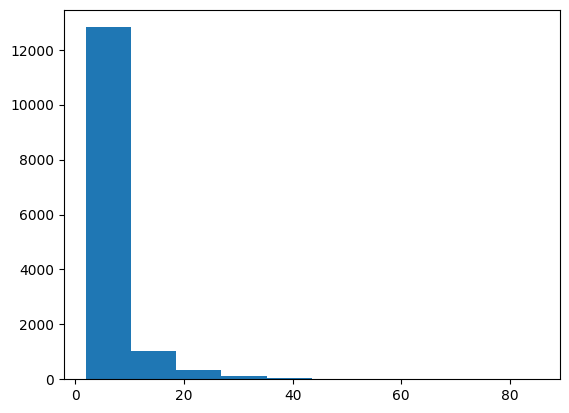

In [53]:
plt.hist([len(c) for c in conn_b_touch])

(array([5254., 3838., 1868., 1233., 1231.,  423.,  356.,  142.,   46.,
          15.]),
 array([0.69314718, 1.06809759, 1.443048  , 1.8179984 , 2.19294881,
        2.56789922, 2.94284963, 3.31780003, 3.69275044, 4.06770085,
        4.44265126]),
 <BarContainer object of 10 artists>)

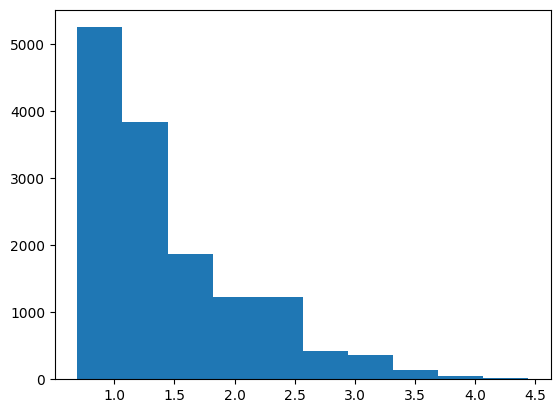

In [54]:
plt.hist([np.log(len(c)) for c in conn_b])

(array([5254., 3838., 1868., 1233., 1231.,  423.,  356.,  142.,   46.,
          15.]),
 array([0.69314718, 1.06809759, 1.443048  , 1.8179984 , 2.19294881,
        2.56789922, 2.94284963, 3.31780003, 3.69275044, 4.06770085,
        4.44265126]),
 <BarContainer object of 10 artists>)

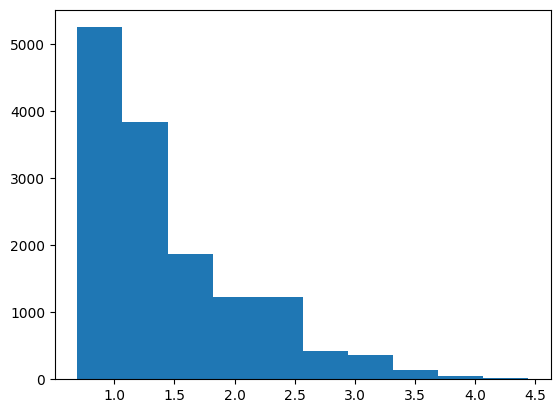

In [55]:
plt.hist([np.log(len(c)) for c in conn_b_touch])

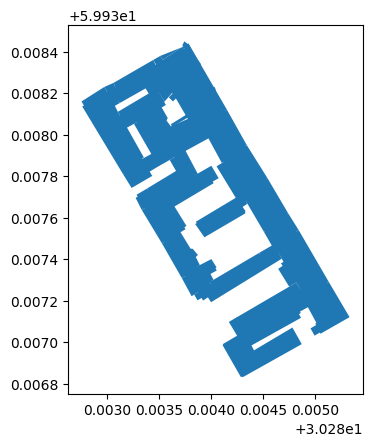

In [16]:
i = 30

plot_together(conn_c[i], b_start, gdf_a, gdf_b)

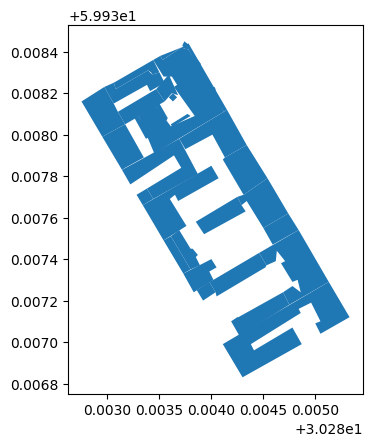

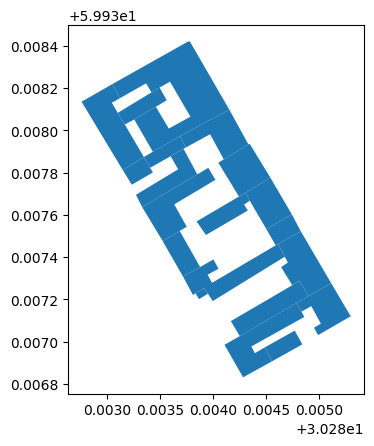

In [17]:
plot_decomposition(conn_c[i], b_start, gdf_a, gdf_b)

In [18]:
jaccard_decomp(conn_c[i], b_start, gdf_a, gdf_b)

0.7910639991496635

In [25]:
np.any(gdf_a.geometry.to_crs('EPSG:4326').area == 0)

/tmp/ipykernel_113921/458937426.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  np.any(gdf_a.geometry.to_crs('EPSG:4326').area == 0)


np.False_

In [ ]:
for shape in gdf_a.geometry:
    print(shape)
    break

MULTIPOLYGON (((30.10095 59.82052, 30.10085 59.82046, 30.10078 59.82048, 30.10076 59.82048, 30.10083 59.82054, 30.10076 59.82056, 30.10078 59.82058, 30.10095 59.82052)), ((30.10074 59.82045, 30.10065 59.82049, 30.10068 59.82051, 30.10076 59.82048, 30.10074 59.82045)))


In [75]:
a_part, b_part = get_decomposition(conn_c[5], b_start, gdf_a, gdf_b)

a_part.head()

,id,title,tags,geometry,area_sq_m,gkh_address,gkh_floor_count_min,gkh_floor_count_max
50240,50241,NaN,['жилое здание'],"POLYGON ((30.26752 59.86817, 30.26657 59.86865...",1161.835,"г. Санкт-Петербург, ул. Маринеско, д. 12, лит. А",5.0,5.0


0.8808452926003826

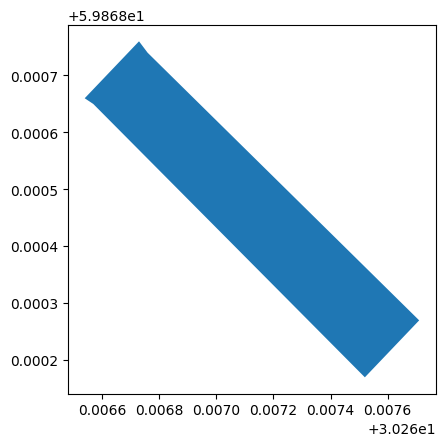

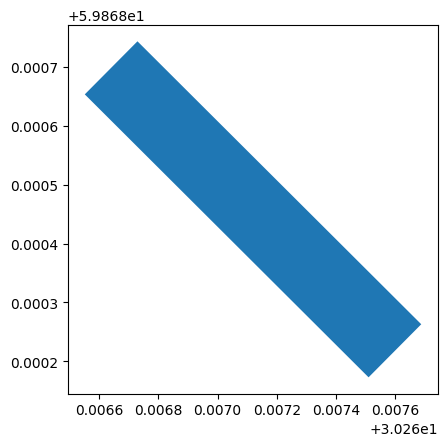

In [73]:
plot_decomposition(conn_c[5], b_start, gdf_a, gdf_b)

In [38]:
!pip3 install ymaps

  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)
Using cached anyio-4.12.1-py3-none-any.whl (113 kB)
Using cached idna-3.11-py3-none-any.whl (71 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
